In [ ]:
### --------------- HOMEWORK 1 --------------
### template copied from tutorial 1 and 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from matplotlib import cm, rc

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate, train_test_split
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV

from sklearn import metrics
from sklearn.preprocessing import StandardScaler

In [ ]:

######### LOAD DATA
######### The data consists of 16*10000 samples taken in T=np.arange(0.25,4.0001,0.25):
data_file_name = 'Ising2DFM_reSample_L40_T=All.pkl'
######### The labels are obtained from the following file:
label_file_name = 'Ising2DFM_reSample_L40_T=All_labels.pkl'


############ DATA
with open(data_file_name, 'rb') as pickle_file:
    data = pickle.load(pickle_file) 
print(data.shape)

data = np.unpackbits(data).reshape(-1, 1600)
data=data.astype('int')

#### map 0 state to -1 (Ising variable can take values +/-1)
data[np.where(data==0)]=-1

###### READ LABELS (convention is 1 for ordered states and 0 for disordered states)
with open(label_file_name, 'rb') as pickle_file:
    labels = pickle.load(pickle_file) # pickle reads the file and returns the Python object (here just a 1D array with the binary labels)
print(data.shape) # the shape of the features
print(np.unique(labels)) # the unique labels

C:\Users\fabbasi\AppData\Local\Temp\ipykernel_42872\2613471677.py:14: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(pickle_file) # pickle reads the file and returns the Python object (1D array, compressed bits) and store in data


(32000000,)
(160000, 1600)
[0 1]


C:\Users\fabbasi\AppData\Local\Temp\ipykernel_42872\2613471677.py:30: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  labels = pickle.load(pickle_file) # pickle reads the file and returns the Python object (here just a 1D array with the binary labels)


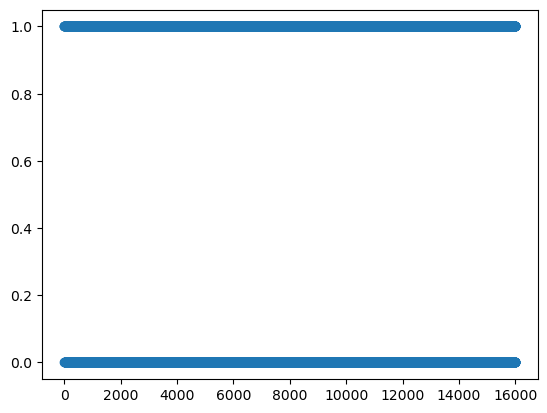

In [ ]:
np.random.seed(228) #this random seed is carefully chosen so that one example is very special in the future

sel = np.random.choice(data.shape[0], data.shape[0]//10, replace = False)

seldata = data[sel,:] # for all indices, select all data
sellabels = labels[sel]
plt.scatter(np.arange(seldata.shape[0]),sellabels); #The random selection has the advantage of reshuffling the data!

In [10]:
## PROBLEM 2 (a)
model = LogisticRegression(max_iter = 1000)
results = cross_validate(model, seldata, sellabels,
                         cv = KFold(n_splits=5, shuffle=True, random_state=10), scoring=("accuracy", "recall", "precision", "f1_macro"), return_train_score = True)

print("train score (accuracy): ")
print(np.round(results['train_accuracy'].mean(), 3).item(), np.round(results['train_accuracy'].std(), 3).item())
print("test score (accuracy): ")
print(np.round(results['test_accuracy'].mean(), 3).item(), np.round(results['test_accuracy'].std(), 3).item())

print("train score (recall): ")
print(np.round(results['train_recall'].mean(), 3).item(), np.round(results['train_recall'].std(), 3).item())
print("test score (recall): ")
print(np.round(results['test_recall'].mean(), 3).item(), np.round(results['test_recall'].std(), 3).item())


print("train score (precision): ")
print(np.round(results['train_precision'].mean(), 3).item(), np.round(results['train_precision'].std(), 3).item())
print("test score (precision): ")
print(np.round(results['test_precision'].mean(), 3).item(), np.round(results['test_precision'].std(), 3).item())

print("train score (F1 score): ")
print(np.round(results['train_f1_macro'].mean(), 3).item(), np.round(results['train_f1_macro'].std(), 3).item())
print("test score (F1 score): ")
print(np.round(results['test_f1_macro'].mean(), 3).item(), np.round(results['test_f1_macro'].std(), 3).item())


train score (accuracy): 
0.779 0.003
test score (accuracy): 
0.684 0.002
train score (recall): 
0.938 0.002
test score (recall): 
0.914 0.005
train score (precision): 
0.738 0.002
test score (precision): 
0.657 0.003
train score (F1 score): 
0.761 0.003
test score (F1 score): 
0.643 0.004


In [ ]:
T = np.arange(0.25, 4.0001, 0.25)

In [ ]:
## PROBLEM 2 (b)
model = LogisticRegression(max_iter = 1000)
pred = cross_val_predict(model, seldata, sellabels,
                         cv = KFold(n_splits=5, shuffle=True, random_state=10))

In [30]:
sel_temps = T[sel // 10000] # 10000 items in each temperature 

In [38]:
acc = []

for t in T: 
    size_block = sellabels[np.where(sel_temps == t)].shape[0]
    acc_T = np.sum(sellabels[np.where(sel_temps == t)]  == pred[np.where(sel_temps == t)]) / size_block
    acc.append(acc_T)

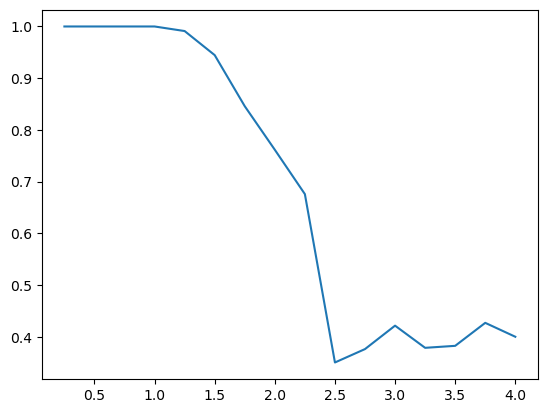

In [39]:
plt.figure()
plt.plot(T, acc, label="average accuracy")

plt.show()

In [11]:
from sklearn.pipeline import make_pipeline
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101) # stratified, preserve label random_state: easy to reproduce the splitting

In [12]:
piped_model = make_pipeline(StandardScaler(), SVC(kernel="poly", degree=2, C=1.0))
poly_piped = cross_val_predict(piped_model, seldata, sellabels, cv = cv, n_jobs=-1)

In [40]:
acc = []

for t in T: 
    size_block = sellabels[np.where(sel_temps == t)].shape[0]
    acc_T = np.sum(sellabels[np.where(sel_temps == t)]  == poly_piped[np.where(sel_temps == t)]) / size_block
    acc.append(acc_T)

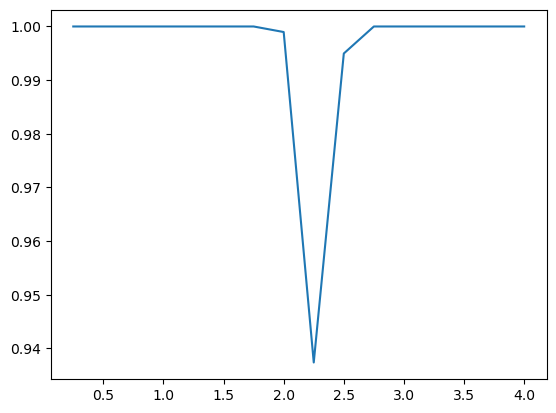

In [41]:
plt.figure()
plt.plot(T, acc, label="average accuracy")

plt.show()

In [15]:
piped_model = make_pipeline(StandardScaler(), SVC(kernel="rbf"))
rbf_piped = cross_val_predict(piped_model, seldata, sellabels, cv = cv)

In [44]:
acc = []

for t in T: 
    size_block = sellabels[np.where(sel_temps == t)].shape[0]
    acc_T = np.sum(sellabels[np.where(sel_temps == t)]  == rbf_piped[np.where(sel_temps == t)]) / size_block
    acc.append(acc_T)

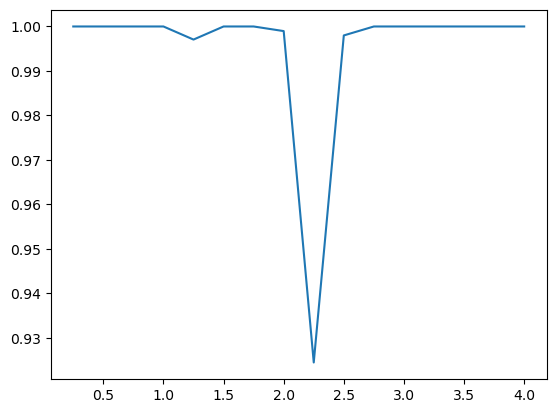

In [45]:
plt.figure()
plt.plot(T, acc, label="average accuracy")

plt.show()